# svm implementaion on manual lineraly separable data

In [ ]:
# IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

In [ ]:
# LET'S TAKE THE DATA

In [ ]:
x=np.array([[1,2],[2,3],[3,3],[6,5],[7,8],[8,8]])
y=np.array([0,0,0,1,1,1])

In [ ]:
model=svm.SVC(kernel='linear')
model.fit(x,y)

SVC(kernel='linear')

In [ ]:
# plot the graph

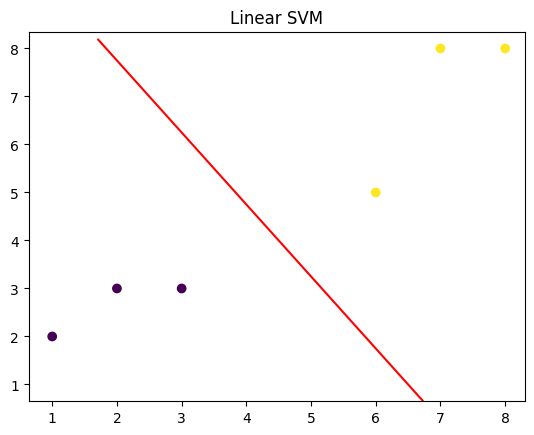

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
ax=plt.gca()
xlim=ax.get_xlim()
ylim=ax.get_ylim()
xx=np.linspace(xlim[0],xlim[1],30)
yy=np.linspace(ylim[0],ylim[1],30)
xx,yy=np.meshgrid(yy,xx)
xy=np.vstack([xx.ravel(),yy.ravel()]).T
z=model.decision_function(xy).reshape(xx.shape)
plt.contour(xx,yy,z,levels=[0],colors="red")
plt.title("Linear SVM")
plt.show()

# svm implementation on manual non-linealy seperable data...

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

In [ ]:
x,y=make_circles(n_samples=200,noise=0.1,factor=0.5,random_state=42)
model=SVC(kernel="rbf")
model.fit(x,y)

SVC()

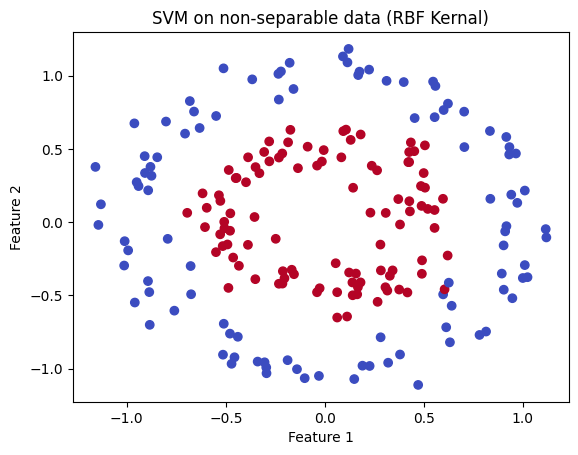

Model trained successfully


In [ ]:
plt.scatter(x[:,0],x[:,1],c=y,cmap="coolwarm")
plt.title("SVM on non-separable data (RBF Kernal)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
print("Model trained successfully")

# svm on randomly generated data

Accuracy: 0.9555555555555556

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        46
           1       0.95      0.95      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



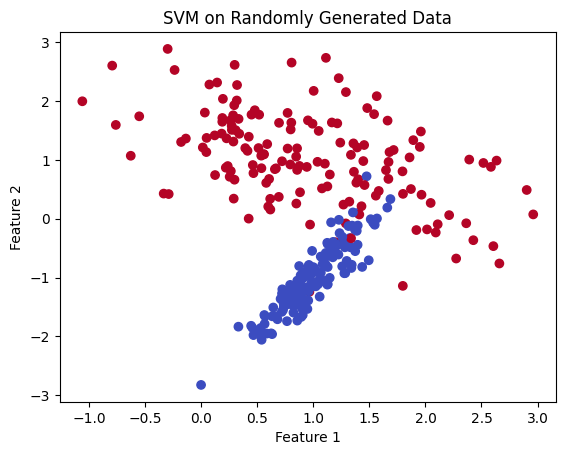

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

x, y = make_classification(n_samples=300,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           random_state=42)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

plt.scatter(x[:, 0],x[:, 1], c=y, cmap='coolwarm')
plt.title("SVM on Randomly Generated Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# svm on a dataset download from kaggle


In [31]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv("test.csv")
data.head()

categorical_cols = data.select_dtypes(include=['object']).columns
print(f"\nCategorical columns identified: {list(categorical_cols)}")

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])
    print(f"Column '{col}' encoded successfully.")

# Fix: Changed 'placement_status' to 'Placement_Status' to match the actual column name
x = data.drop('Placement_Status', axis=1)
y = data['Placement_Status']

scaler = StandardScaler()
x = scaler.fit_transform(x)
print("\nFeatures scaled successfully")

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print("\nData split successfully")

model = SVC(kernel='rbf')
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Categorical columns identified: ['Gender', 'Degree', 'Branch', 'Placement_Status']
Column 'Gender' encoded successfully.
Column 'Degree' encoded successfully.
Column 'Branch' encoded successfully.
Column 'Placement_Status' encoded successfully.

Features scaled successfully

Data split successfully

Accuracy: 0.956

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       936
           1       0.95      0.93      0.94       564

    accuracy                           0.96      1500
   macro avg       0.96      0.95      0.95      1500
weighted avg       0.96      0.96      0.96      1500

